# Pima Diabetes Monitoring Walkthrough

This notebook walks through a complete local `lumosai` workflow using the Pima Indians Diabetes dataset. It shows raw and preprocessed data reporting, pre/post calibration checks, low-level reports, and the training/monitoring bundles you would use once the pipeline shape is stable.

The example stays local by default. Set `EXPERIMENT_NAME = "pima-diabetes-demo"` to log the report outputs to MLflow.


## 1. Imports and data

The CSV lives in `examples/data/diabetes.csv`. It is the Kaggle `uciml/pima-indians-diabetes-database` download, checked into this repo so the notebook can run without Kaggle credentials.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from lumosai import monitoring_report, training_report
from lumosai.data import build_sample, drift_report, profile
from lumosai.model import bias_report, calibration_report, feature_importance, performance_report
from lumosai.settings import Settings

EXPERIMENT_NAME = None  # Set to "pima-diabetes-demo" to log to MLflow.


def display_html_artifact(result, title: str) -> None:
    artifact = result.artifacts.get("html")
    print(title)
    if isinstance(artifact, str):
        display(HTML(Path(artifact).read_text(encoding="utf-8")))
    else:
        display(artifact)

data_candidates = [
    Path("examples/data/diabetes.csv"),
    Path("../data/diabetes.csv"),
]
data_path = next(path for path in data_candidates if path.exists())

raw = pd.read_csv(data_path)
raw.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Enrich the raw dataset

The source data is a static table. For reporting we derive:

- `encounter_date`, so drift reports can exclude temporal fields and samples can use temporal strategies.
- `age_group`, so bias reports have an honest review slice.

Gender is intentionally not used. The Pima dataset does not include gender and the cohort is women, so a gender bias report would be fabricated rather than informative.


In [2]:
target = "Outcome"
model_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]
report_features = [*model_features, "age_group"]
categorical_columns = ["age_group"]
invalid_zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]


def add_reporting_columns(frame: pd.DataFrame) -> pd.DataFrame:
    enriched = frame.copy()
    enriched["encounter_date"] = pd.date_range("2024-01-01", periods=len(enriched), freq="D")
    enriched["age_group"] = pd.cut(
        enriched["Age"],
        bins=[20, 30, 40, 50, 100],
        labels=["20-29", "30-39", "40-49", "50+"],
        include_lowest=True,
    ).astype("string")
    return enriched


def preprocess_measurements(frame: pd.DataFrame) -> pd.DataFrame:
    processed = frame.copy()
    processed[invalid_zero_columns] = processed[invalid_zero_columns].replace(0, np.nan)
    return processed


raw_enriched = add_reporting_columns(raw)
preprocessed = preprocess_measurements(raw_enriched)

pd.DataFrame(
    {
        "raw_missing": raw_enriched[model_features].isna().sum(),
        "preprocessed_missing": preprocessed[model_features].isna().sum(),
    }
)


,raw_missing,preprocessed_missing
Pregnancies,0,0
Glucose,0,5
BloodPressure,0,35
SkinThickness,0,227
Insulin,0,374
BMI,0,11
DiabetesPedigreeFunction,0,0
Age,0,0


## 3. Log raw and preprocessed data boundaries

Run separate reports before and after preprocessing so the pipeline has an audit trail. In a real pipeline these calls would usually sit on either side of the preprocessing job.


In [3]:
raw_profile = profile(
    raw_enriched,
    target=target,
    feature_columns=report_features,
    categorical_columns=categorical_columns,
    time_column="encounter_date",
    minimal=True,
    report_name="Pima Raw Profile",
    experiment_name=EXPERIMENT_NAME,
)
preprocessed_profile = profile(
    preprocessed,
    target=target,
    feature_columns=report_features,
    categorical_columns=categorical_columns,
    time_column="encounter_date",
    minimal=True,
    report_name="Pima Preprocessed Profile",
    experiment_name=EXPERIMENT_NAME,
)
raw_sample = build_sample(
    raw_enriched,
    role="train_benchmark",
    target=target,
    feature_columns=report_features,
    categorical_columns=categorical_columns,
    time_column="encounter_date",
    sample_size=200,
    experiment_name=EXPERIMENT_NAME,
)

preprocessed_sample = build_sample(
    preprocessed,
    role="train_benchmark",
    target=target,
    feature_columns=report_features,
    categorical_columns=categorical_columns,
    time_column="encounter_date",
    sample_size=200,
    experiment_name=EXPERIMENT_NAME,
)

{
    "raw_profile_artifacts": raw_profile.artifacts,
    "preprocessed_profile_artifacts": preprocessed_profile.artifacts,
    "raw_sample_rows": raw_sample.summary["sample_rows"],
    "preprocessed_sample_rows": preprocessed_sample.summary["sample_rows"],
}


/Users/rmenzie/code/lumos-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/16 [00:00<?, ?it/s, Describe variable: Outcome]

Summarize dataset:   0%|          | 0/16 [00:00<?, ?it/s, Describe variable: Age]    

Summarize dataset:   6%|▋         | 1/16 [00:00<00:00, 115.07it/s, Describe variable: encounter_date]

...

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML: 100%|██████████| 1/1 [00:00<00:00, 41.71it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 1112.25it/s]

{'raw_profile_artifacts': {'html': 'lumosai-artifacts/profile.html'},
 'preprocessed_profile_artifacts': {'html': 'lumosai-artifacts/profile.html'},
 'raw_sample_rows': 200,
 'preprocessed_sample_rows': 200}

In [4]:
for title, result in [
    ("Raw profile", raw_profile),
    ("Preprocessed profile", preprocessed_profile),
]:
    display_html_artifact(result, title)


Raw profile


Preprocessed profile


## 4. Split training, holdout, and monitoring windows

The example uses row order as a stand-in for time. The training frame becomes the benchmark, the holdout frame evaluates model quality after training, and the current window acts like a later production slice.


In [5]:
train_end = int(len(preprocessed) * 0.60)
holdout_end = int(len(preprocessed) * 0.80)

train_frame = preprocessed.iloc[:train_end].copy()
holdout_frame = preprocessed.iloc[train_end:holdout_end].copy()
previous_window = preprocessed.iloc[train_end:holdout_end].copy()
current_window = preprocessed.iloc[holdout_end:].copy()

train_frame.shape, holdout_frame.shape, current_window.shape


((460, 11), (154, 11), (154, 11))

## 5. Train an uncalibrated model and a calibrated model

A random forest is intentionally useful here: its raw probabilities can be imperfectly calibrated. `CalibratedClassifierCV` then learns a probability calibration layer on the holdout window. This keeps the example small while making pre/post calibration reports meaningful.


In [6]:
base_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", RandomForestClassifier(n_estimators=250, min_samples_leaf=8, random_state=42)),
    ]
)
base_model.fit(train_frame[model_features], train_frame[target])

calibrated_model = CalibratedClassifierCV(FrozenEstimator(base_model), method="sigmoid")
calibrated_model.fit(holdout_frame[model_features], holdout_frame[target])

score_labels = [int(label) for label in base_model.classes_]
positive_index = score_labels.index(1)


def score_frame(frame: pd.DataFrame, model, prefix: str) -> pd.DataFrame:
    scored = frame.copy()
    probabilities = model.predict_proba(scored[model_features])
    scored[f"{prefix}_prediction"] = model.predict(scored[model_features])
    scored[f"{prefix}_prediction_score"] = list(probabilities)
    scored[f"{prefix}_positive_probability"] = probabilities[:, positive_index]
    return scored


holdout_scored = score_frame(holdout_frame, base_model, "raw_model")
calibrated_holdout_scored = score_frame(holdout_scored, calibrated_model, "calibrated_model")
previous_scored = score_frame(previous_window, calibrated_model, "calibrated_model")
current_scored = score_frame(current_window, calibrated_model, "calibrated_model")

calibrated_holdout_scored[
    [target, "raw_model_prediction", "raw_model_positive_probability", "calibrated_model_positive_probability"]
].head()


,Outcome,raw_model_prediction,raw_model_positive_probability,calibrated_model_positive_probability
460,0,0,0.223483,0.058239
461,0,0,0.032263,0.012437
462,0,0,0.228172,0.060416
463,0,0,0.238303,0.065383
464,0,0,0.333490,0.133805


## 6. Compare calibration before and after calibration

Run `calibration_report()` on both score sets. The exact improvement can vary by dataset split and model, so compare the metrics rather than assuming calibration always wins on every small sample.


Pre-calibration report



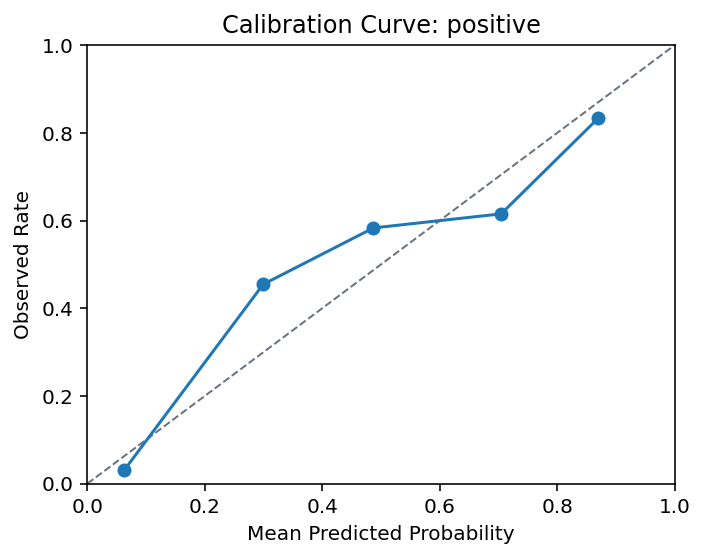

Post-calibration report



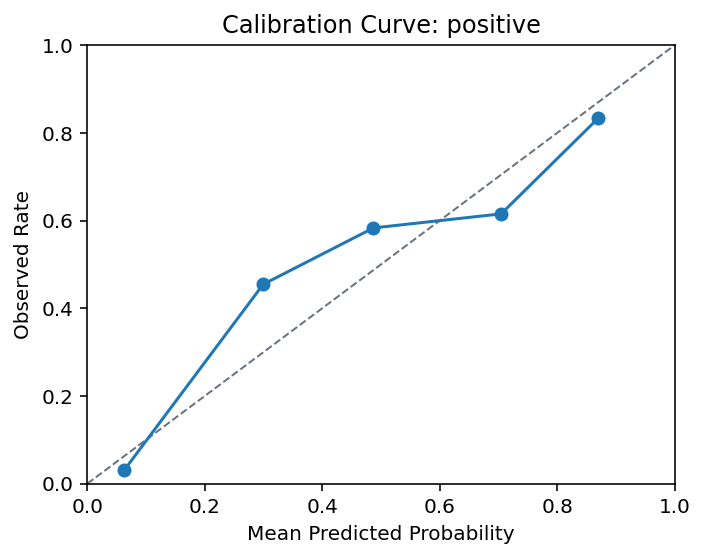

In [7]:
pre_calibration = calibration_report(
    calibrated_holdout_scored,
    target=target,
    prediction_score="raw_model_prediction_score",
    score_labels=score_labels,
    n_bins=5,
    report_name="Pima Pre Calibration",
    experiment_name=EXPERIMENT_NAME,
)

post_calibration = calibration_report(
    calibrated_holdout_scored,
    target=target,
    prediction_score="calibrated_model_prediction_score",
    score_labels=score_labels,
    n_bins=5,
    report_name="Pima Post Calibration",
    experiment_name=EXPERIMENT_NAME,
)

pd.DataFrame(
    {
        "pre_calibration": pre_calibration.metrics,
        "post_calibration": post_calibration.metrics,
    }
).loc[["calibration/positive/brier", "calibration/positive/ece", "calibration/macro_brier", "calibration/macro_ece"]]

display_html_artifact(pre_calibration, "Pre-calibration report")
display_html_artifact(post_calibration, "Post-calibration report")


## 7. Run holdout performance, lift, bias, and feature importance

`performance_report()` accepts sklearn-style probability arrays through the `prediction_score` column. `bias_report()` currently uses the scalar positive-class probability column for score-aware group metrics.


Holdout performance report


Metric,Value
accuracy,0.824675
f1,0.816173
lift/positive/decile_1,2.78618
lift/positive/decile_10,0
lift/positive/decile_2,3.03947
lift/positive/decile_3,1.77303
lift/positive/decile_4,1.51974
lift/positive/decile_5,0.270175
lift/positive/decile_6,0.270175
lift/positive/decile_7,0

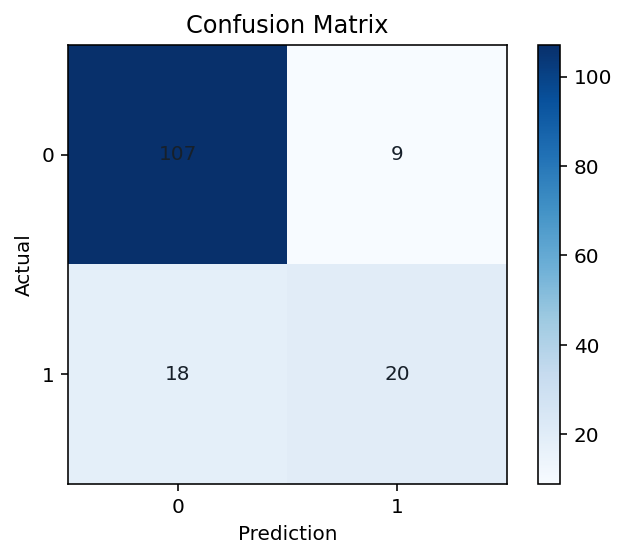
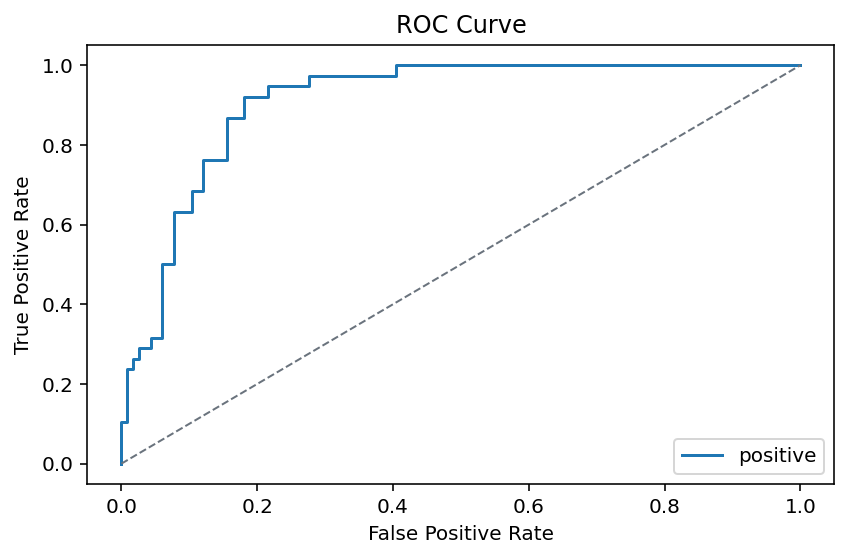
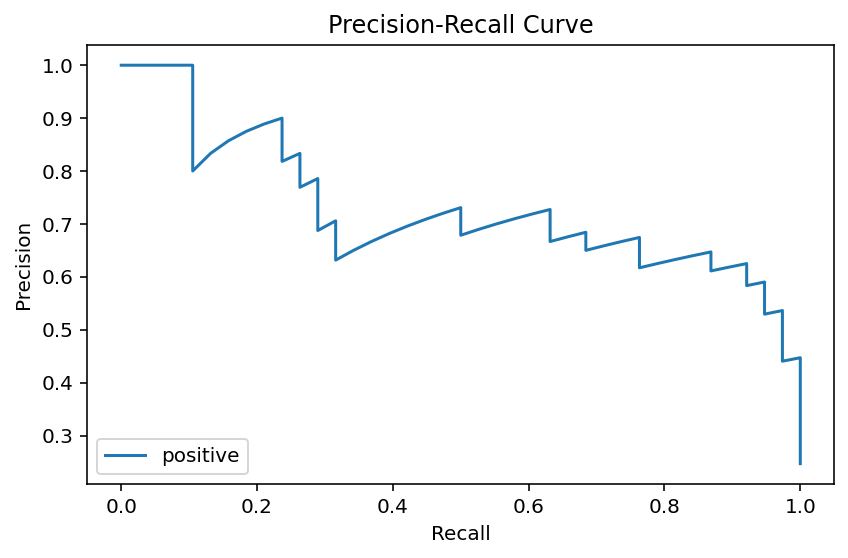
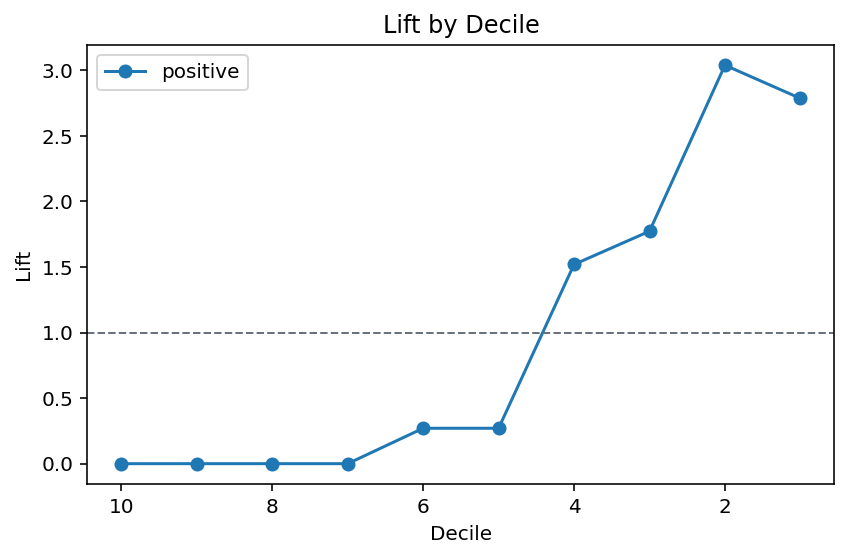

Feature importance report



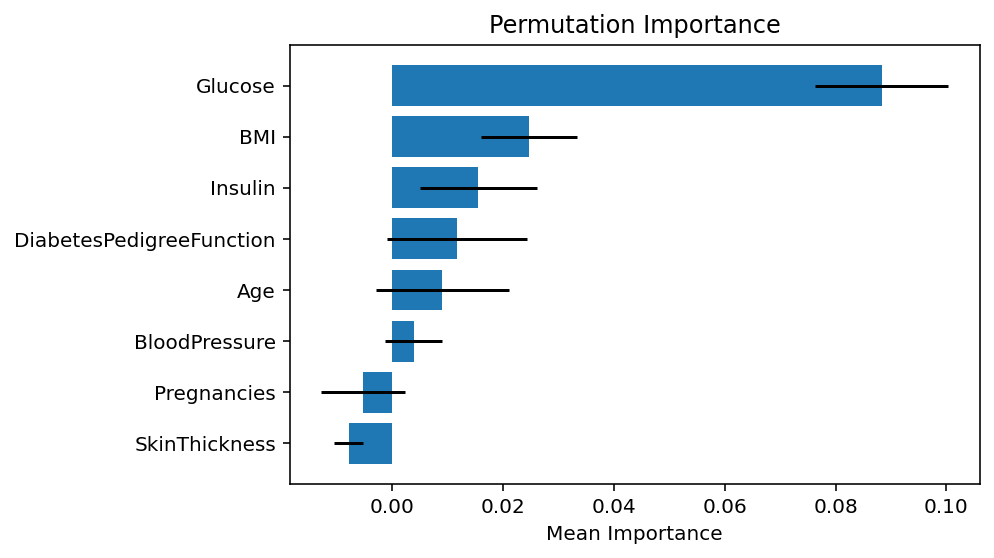

In [8]:
performance = performance_report(
    calibrated_holdout_scored,
    target=target,
    prediction="calibrated_model_prediction",
    prediction_score="calibrated_model_prediction_score",
    score_labels=score_labels,
    include_lift=True,
    feature_columns=model_features,
    report_name="Pima Holdout Performance",
    experiment_name=EXPERIMENT_NAME,
)

bias = bias_report(
    calibrated_holdout_scored,
    target=target,
    prediction="calibrated_model_prediction",
    protected_attribute=["age_group"],
    prediction_score="calibrated_model_positive_probability",
    feature_columns=model_features,
    report_name="Pima Holdout Age Group Bias",
    experiment_name=EXPERIMENT_NAME,
)

importance = feature_importance(
    calibrated_model,
    calibrated_holdout_scored,
    target=target,
    feature_columns=model_features,
    method="permutation",
    report_name="Pima Feature Importance",
    experiment_name=EXPERIMENT_NAME,
)

pd.Series(performance.metrics).sort_index().head(12)

display_html_artifact(performance, "Holdout performance report")
display_html_artifact(importance, "Feature importance report")


In [9]:
bias.flagged[:5]


[{'metric': 'accuracy',
  'comparison_mode': 'relative',
  'group_value': 0.6842105263157895,
  'best_value': 0.9024390243902439,
  'diff': -0.21822849807445444,
  'ratio': 0.7581792318634424,
  'threshold': 0.8,
  'flagged': True,
  'group': '40-49',
  'protected_attribute': 'age_group'},
 {'metric': 'accuracy',
  'comparison_mode': 'relative',
  'group_value': 0.6818181818181818,
  'best_value': 0.9024390243902439,
  'diff': -0.22062084257206216,
  'ratio': 0.7555282555282554,
  'threshold': 0.8,
  'flagged': True,
  'group': '50+',
  'protected_attribute': 'age_group'},
 {'metric': 'f1',
  'comparison_mode': 'relative',
  'group_value': 0.6558704453441295,
  'best_value': 0.8834843205574914,
  'diff': -0.22761387521336185,
  'ratio': 0.7423679516239358,
  'threshold': 0.8,
  'flagged': True,
  'group': '40-49',
  'protected_attribute': 'age_group'},
 {'metric': 'f1',
  'comparison_mode': 'relative',
  'group_value': 0.6783521489403842,
  'best_value': 0.8834843205574914,
  'diff': -

In [10]:
importance.summary["features"][:5]


[{'feature': 'Glucose',
  'importance_mean': 0.08831168831168831,
  'importance_std': 0.012043660383760665},
 {'feature': 'BMI',
  'importance_mean': 0.024675324675324673,
  'importance_std': 0.00861460984507897},
 {'feature': 'Insulin',
  'importance_mean': 0.015584415584415567,
  'importance_std': 0.01055069922679993},
 {'feature': 'DiabetesPedigreeFunction',
  'importance_mean': 0.01168831168831166,
  'importance_std': 0.012591376253029455},
 {'feature': 'Age',
  'importance_mean': 0.009090909090909061,
  'importance_std': 0.01204366038376064}]

## 8. Compare drift windows

Data drift is the comparison report. Performance, calibration, and bias normally trend through repeated runs over time.


In [11]:
benchmark_drift = drift_report(
    reference=train_frame,
    current=current_scored,
    temporal_features=["encounter_date"],
    feature_columns=report_features,
    categorical_columns=categorical_columns,
    comparison="benchmark",
    report_name="Pima Benchmark Drift",
    experiment_name=EXPERIMENT_NAME,
)

previous_window_drift = drift_report(
    reference=previous_scored,
    current=current_scored,
    temporal_features=["encounter_date"],
    feature_columns=report_features,
    categorical_columns=categorical_columns,
    comparison="previous_window",
    report_name="Pima Previous Window Drift",
    experiment_name=EXPERIMENT_NAME,
)

pd.Series(benchmark_drift.metrics).sort_index().head(12)

display_html_artifact(benchmark_drift, "Benchmark drift report")
display_html_artifact(previous_window_drift, "Previous-window drift report")


Benchmark drift report


Field,Value
report_type,drift
comparison,benchmark
dataset_drift,False
n_drifted_columns,1
share_drifted_columns,0.1


Previous-window drift report


Field,Value
report_type,drift
comparison,benchmark
dataset_drift,False
n_drifted_columns,1
share_drifted_columns,0.1


## 9. Promote the stable flow to bundles

Once the low-level report boundaries look right, use bundles for repeated pipeline runs. The training bundle groups sample, performance, bias, and feature importance results. The monitoring bundle groups window sample, benchmark drift, optional previous-window drift, performance, and bias.


In [12]:
notebook_settings = Settings()
notebook_settings.model.feature_importance_method = "permutation"

training_run = training_report(
    train_frame,
    calibrated_holdout_scored,
    target=target,
    prediction="calibrated_model_prediction",
    prediction_score="calibrated_model_positive_probability",
    model=calibrated_model,
    feature_columns=model_features,
    protected_attribute="age_group",
    time_column="encounter_date",
    sample_size=150,
    include_profile=False,
    include_feature_importance=True,
    report_name="Pima Training",
    experiment_name=EXPERIMENT_NAME,
    loaded_settings=notebook_settings,
)

training_run.results.keys()


dict_keys(['train_sample', 'holdout_sample', 'performance', 'bias', 'feature_importance'])

In [13]:
monitoring_run = monitoring_report(
    current_scored,
    benchmark=train_frame,
    previous_window=previous_scored,
    target=target,
    prediction="calibrated_model_prediction",
    prediction_score="calibrated_model_positive_probability",
    feature_columns=report_features,
    categorical_columns=categorical_columns,
    protected_attribute="age_group",
    temporal_features=["encounter_date"],
    sample_size=150,
    report_name="Pima Monitoring",
    experiment_name=EXPERIMENT_NAME,
)

monitoring_run.results.keys()


dict_keys(['monitoring_window', 'drift_benchmark', 'drift_previous_window', 'performance', 'bias'])

## 10. What to log in production

For real pipelines, keep the same dataframe contracts and set `experiment_name` or `LUMOSAI_MLFLOW__DEFAULT_EXPERIMENT_NAME` so reports log into MLflow. Keep raw sample artifact logging opt-in when datasets contain sensitive fields.
